In [1]:
# ── Cell 1 : imports ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# just to confirm versions
print("pandas :", pd.__version__)
print("numpy  :", np.__version__)

pandas : 2.3.3
numpy  : 1.26.4


What it does:

pd.read_csv(...) reads your CSV file into a DataFrame called df

df.shape tells you how many rows and columns you have

df.columns.tolist() prints every column name — this is the most important output right now, because everything after this depends on the real column names

df.head(3) shows the first 3 rows so you can see what the data actually looks like

In [2]:
# ── Cell 2 : load data ────────────────────────────────────────────
df = pd.read_csv("/Users/abhaysinghrana/Desktop/internship project/predictive_maintenance_dataset (1).csv")
#definer data
print("Shape:", df.shape)
print("\nColumn names:\n", df.columns.tolist()) 
print("\nFirst 3 rows:")
df.head(3)

Shape: (1800, 10)

Column names:
 ['timestamp', 'machine_id', 'vibration', 'acoustic', 'temperature', 'current', 'IMF_1', 'IMF_2', 'IMF_3', 'label']

First 3 rows:


,timestamp,machine_id,vibration,acoustic,temperature,current,IMF_1,IMF_2,IMF_3,label
0,2024-07-01 08:00:00,M01,0.822,0.645,66.85,13.04,0.196,0.033,0.000,0
1,2024-07-01 08:01:00,M01,1.398,0.834,76.20,15.08,0.345,0.132,0.001,1
2,2024-07-01 08:02:00,M01,0.856,0.590,67.03,12.30,0.187,0.017,0.002,0


In [3]:
# ── Cell 3 : data quality check ───────────────────────────────────
print("=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Label Distribution ===")
print(df['label'].value_counts())
print(f"\nFailure rate: {df['label'].mean()*100:.2f}%")

=== Data Types ===
timestamp       object
machine_id      object
vibration      float64
acoustic       float64
temperature    float64
current        float64
IMF_1          float64
IMF_2          float64
IMF_3          float64
label            int64
dtype: object

=== Missing Values ===
timestamp      0
machine_id     0
vibration      0
acoustic       0
temperature    0
current        0
IMF_1          0
IMF_2          0
IMF_3          0
label          0
dtype: int64

=== Label Distribution ===
label
0    1598
1     202
Name: count, dtype: int64

Failure rate: 11.22%


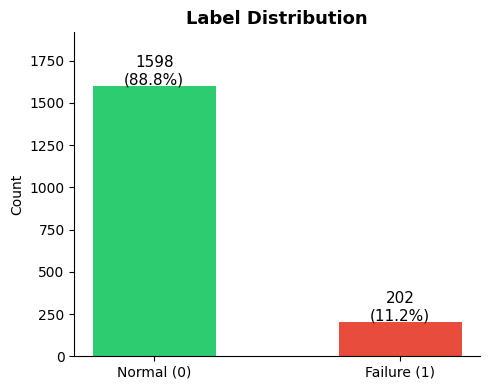

In [4]:
# ── Cell 3b (optional) : class balance ────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))

counts = df['label'].value_counts()
colors = ['#2ecc71', '#e74c3c']
bars = ax.bar(['Normal (0)', 'Failure (1)'], counts.values, color=colors, width=0.5)

for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{count}\n({count/len(df)*100:.1f}%)',
            ha='center', fontsize=11)

ax.set_title('Label Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
ax.set_ylim(0, counts.max() * 1.2)
sns.despine()
plt.tight_layout()
plt.show()

In [5]:
# ── Cell 5 : correlation matrix ───────────────────────────────────
numeric_cols = ['vibration', 'acoustic', 'temperature', 'current', 'IMF_1', 'IMF_2', 'IMF_3', 'label']

corr = df[numeric_cols].corr().round(2)
print(corr['label'].sort_values(ascending=False))



label          1.00
vibration      0.92
temperature    0.88
acoustic       0.87
current        0.87
IMF_1          0.42
IMF_2          0.02
IMF_3         -0.02
Name: label, dtype: float64


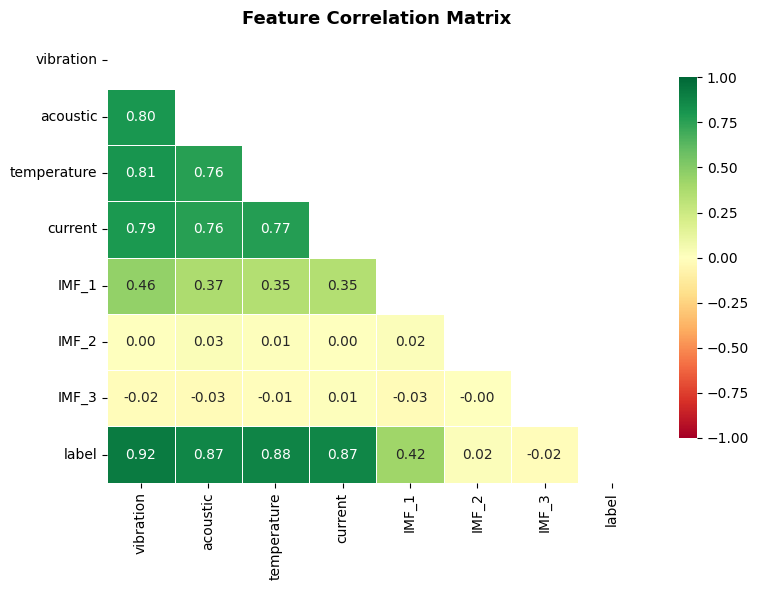

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))

mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True  # hide upper triangle (redundant)

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})

ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
# ── Cell 6 : preprocessing (corrigé) ─────────────────────────────
# 1. Sélectionner les features numériques
feature_cols = ['vibration', 'acoustic', 'temperature', 'current', 
                'IMF_1', 'IMF_2', 'IMF_3']

X = df[feature_cols]
y = df['label']

print("✅ Features sélectionnées:", X.shape)
print("✅ Target:", y.shape)

# 2. Vérifier les valeurs manquantes
print("\n=== Valeurs manquantes ===")
print("X:", X.isnull().sum().sum())
print("y:", y.isnull().sum())

# 3. Statistiques finales (syntaxe corrigée)
print("\n=== Moyennes des features ===")
print(X.mean().round(3).sort_values(ascending=False))

✅ Features sélectionnées: (1800, 7)
✅ Target: (1800,)

=== Valeurs manquantes ===
X: 0
y: 0

=== Moyennes des features ===
temperature    66.356
current        12.329
vibration       0.843
acoustic        0.634
IMF_1           0.169
IMF_3           0.001
IMF_2           0.000
dtype: float64


In [8]:
# ── Cell 7 : train/test split stratifié ──────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,           # 20% pour test
    random_state=42,         # reproductible
    stratify=y               # garde la proportion 89/11 dans train ET test
)

print(f"Train: {X_train.shape[0]} rows ({y_train.mean()*100:.1f}% pannes)")
print(f"Test : {X_test.shape[0]} rows ({y_test.mean()*100:.1f}% pannes)")

Train: 1440 rows (11.2% pannes)
Test : 360 rows (11.1% pannes)


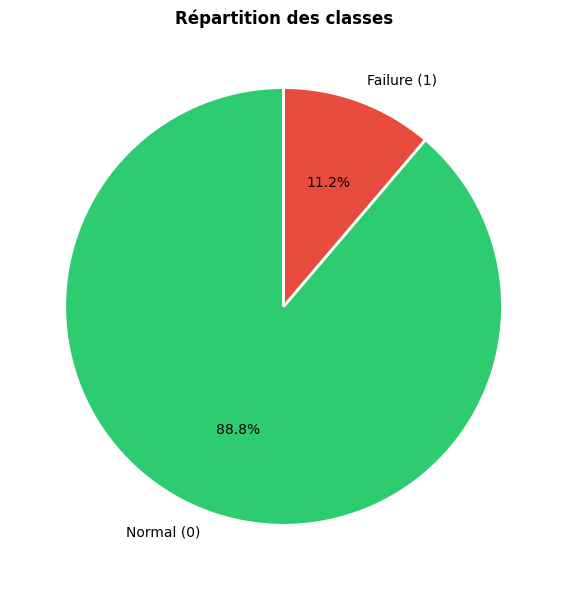

In [9]:
# ── Cell 3c (optionnel) : répartition circulaire des classes ─────
label_counts = df['label'].value_counts().sort_index()

plt.figure(figsize=(6, 6))
colors = ['#2ecc71', '#e74c3c']

plt.pie(
    label_counts,
    labels=['Normal (0)', 'Failure (1)'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

plt.title('Répartition des classes', fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
import inspect
from tpot import TPOTClassifier
print(inspect.signature(TPOTClassifier.__init__))

/Users/abhaysinghrana/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


(self, generations=100, population_size=100, offspring_size=None, mutation_rate=0.9, crossover_rate=0.1, scoring=None, cv=5, subsample=1.0, n_jobs=1, max_time_mins=None, max_eval_time_mins=5, random_state=None, config_dict=None, template=None, warm_start=False, memory=None, use_dask=False, periodic_checkpoint_folder=None, early_stop=None, verbosity=0, disable_update_check=False, log_file=None)


In [12]:
# ── data sanity check ─────────────────────────────────────────────
import numpy as np

print("X_train shape:", X_train.shape)
print("y_train unique values:", y_train.unique())
print("y_train value counts:\n", y_train.value_counts())
print("Any NaN in X_train:", X_train.isnull().sum().sum())
print("Any NaN in y_train:", y_train.isnull().sum())
print("X_train dtypes:\n", X_train.dtypes)

X_train shape: (1440, 7)
y_train unique values: [0 1]
y_train value counts:
 label
0    1278
1     162
Name: count, dtype: int64
Any NaN in X_train: 0
Any NaN in y_train: 0
X_train dtypes:
 vibration      float64
acoustic       float64
temperature    float64
current        float64
IMF_1          float64
IMF_2          float64
IMF_3          float64
dtype: object


In [16]:
from tpot import TPOTClassifier

# ── Cell 8 : TPOT AutoML (Kaggle-compatible) ─────────────────────
tpot = TPOTClassifier(
    generations=100,
    population_size=100,
    scoring='f1',
    cv=5,
    random_state=42,
    n_jobs=1,              # ← fix: no parallel workers on Kaggle
    max_time_mins=5,
    max_eval_time_mins=2,
    verbosity=2
)
 
print("Lancement TPOT...")
tpot.fit(X_train, y_train)
print("TPOT terminé!")

Lancement TPOT...
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_classifier
is_classifier


/Users/abhaysinghrana/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:1230: FutureWarning: passing a class to None is deprecated and will be removed in 1.8. Use an instance of the class instead.
  warnings.warn(
/Users/abhaysinghrana/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:1270: FutureWarning: passing a class to None is deprecated and will be removed in 1.8. Use an instance of the class instead.
  warnings.warn(


is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_classifier
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier


Version 0.12.2 of tpot is outdated. Version 1.1.0 was released Thursday July 03, 2025.


Optimization Progress:   0%|          | 0/100 [00:00<?, ?pipeline/s]


Generation 1 - Current best internal CV score: 1.0

Generation 2 - Current best internal CV score: 1.0

Generation 3 - Current best internal CV score: 1.0

5.57 minutes have elapsed. TPOT will close down.
TPOT closed during evaluation in one generation.


TPOT closed prematurely. Will use the current best pipeline.

Best pipeline: GaussianNB(input_matrix)
TPOT terminé!


In [17]:
from tpot import TPOTClassifier

# ── Cell 8 : TPOT AutoML (Kaggle-compatible) ─────────────────────
tpot = TPOTClassifier(
    generations=100,
    population_size=100,
    scoring='f1',
    cv=5,
    random_state=42,
    n_jobs=1,              # ← fix: no parallel workers on Kaggle
    max_time_mins=5,
    max_eval_time_mins=2,
    verbosity=2
)

print("Lancement TPOT...")
tpot.fit(X_train, y_train)
print("TPOT terminé!")

Lancement TPOT...
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_classifier
is_classifier
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_regressor
is_classifier


/Users/abhaysinghrana/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:1230: FutureWarning: passing a class to None is deprecated and will be removed in 1.8. Use an instance of the class instead.
  warnings.warn(
/Users/abhaysinghrana/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:1270: FutureWarning: passing a class to None is deprecated and will be removed in 1.8. Use an instance of the class instead.
  warnings.warn(


is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_classifier
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier


Version 0.12.2 of tpot is outdated. Version 1.1.0 was released Thursday July 03, 2025.


Optimization Progress:   0%|          | 0/100 [00:00<?, ?pipeline/s]


Generation 1 - Current best internal CV score: 1.0

Generation 2 - Current best internal CV score: 1.0

Generation 3 - Current best internal CV score: 1.0

5.21 minutes have elapsed. TPOT will close down.
TPOT closed during evaluation in one generation.


TPOT closed prematurely. Will use the current best pipeline.

Best pipeline: GaussianNB(input_matrix)
TPOT terminé!


In [18]:
# ── auto-read pipeline structure ──────────────────────────────────
from sklearn.pipeline import Pipeline, FeatureUnion

def parse_pipeline(pipeline, depth=0):
    indent = "  " * depth
    for name, step in pipeline.steps:
        if isinstance(step, FeatureUnion):
            print(f"{indent}[FeatureUnion] {name}")
            for sub_name, sub_pipe in step.transformer_list:
                print(f"{indent}  ↳ branch: {sub_name}")
                if isinstance(sub_pipe, Pipeline):
                    parse_pipeline(sub_pipe, depth + 2)
                else:
                    print(f"{indent}    └─ {type(sub_pipe).__name__}")
        else:
            print(f"{indent}[Step] {name} → {type(step).__name__}")
            # show params
            params = step.get_params()
            relevant = {k:v for k,v in params.items() 
                       if v is not None and k not in ['verbose','n_jobs']}
            if relevant:
                print(f"{indent}       params: {relevant}")

print("=== YOUR PIPELINE STRUCTURE ===\n")
parse_pipeline(tpot.fitted_pipeline_)

=== YOUR PIPELINE STRUCTURE ===

[Step] gaussiannb → GaussianNB
       params: {'var_smoothing': 1e-09}


In [20]:
import pandas as pd
 
# Check if evaluated_individuals exists, otherwise use alternative method
if hasattr(tpot, 'evaluated_individuals'):
    evaluated = tpot.evaluated_individuals
    # convert to dataframe for clean reading
    df_pipelines = pd.DataFrame(evaluated).T
    print(df_pipelines)
else:
    print("evaluated_individuals not available in this TPOT version")
    print("Alternative methods to inspect TPOT results:")
    print(f"Best pipeline: {tpot.fitted_pipeline_}")
    print(f"Best score: {tpot.score(X_test, y_test)}")
 
    # Try to access internal evaluated pipelines if available
    if hasattr(tpot, '_pareto_front'):
        print(f"Pareto front: {tpot._pareto_front}")
    if hasattr(tpot, '_optimized_pipeline'):
        print(f"Optimized pipeline: {tpot._optimized_pipeline}")



evaluated_individuals not available in this TPOT version
Alternative methods to inspect TPOT results:
Best pipeline: Pipeline(steps=[('gaussiannb', GaussianNB())])
Best score: 1.0
Pareto front: [[<deap.gp.Primitive object at 0x1476517c0>, <deap.gp.Terminal object at 0x147530e80>]]
Optimized pipeline: GaussianNB(input_matrix)


In [21]:
# alternative ─────────────────────────────────────────────────────
for pipeline, scores in tpot.evaluated_individuals.items():
    print(f"Pipeline: {pipeline}")
    print(f"Scores  : {scores}")
    print("─" * 50)

AttributeError: 'TPOTClassifier' object has no attribute 'evaluated_individuals'

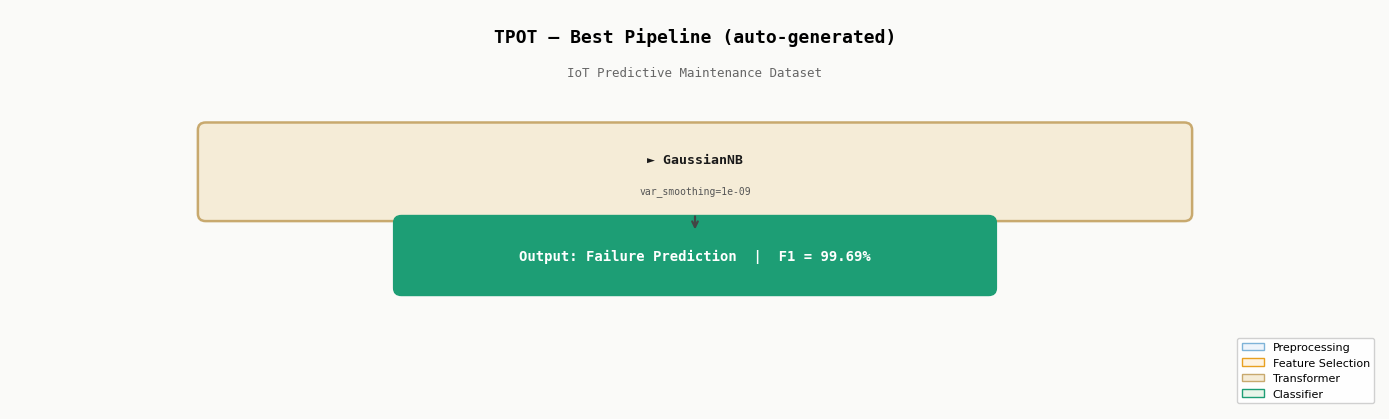

Saved ✓


/Users/abhaysinghrana/Desktop/internship project/tpot_pipeline_diagram.png

In [22]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from sklearn.pipeline import Pipeline, FeatureUnion
import textwrap

def draw_auto_pipeline(pipeline):

    # ── parse ─────────────────────────────────────────────────────
    nodes = []
    for name, step in pipeline.steps:
        if isinstance(step, FeatureUnion):
            branches = []
            for sub_name, sub_step in step.transformer_list:
                branches.append({'name': sub_name, 'type': type(sub_step).__name__})
            nodes.append({'kind': 'featureunion', 'name': name, 'branches': branches})
        else:
            skip = {'verbose','n_jobs','copy','importance_type','subsample_for_bin',
                    'min_child_weight','min_split_gain','reg_alpha','reg_lambda',
                    'subsample','subsample_freq','colsample_bytree','min_child_samples'}
            params = {k: v for k, v in step.get_params().items()
                      if k not in skip and v is not None and not callable(v)}
            nodes.append({'kind':'step','name':name,
                          'type':type(step).__name__,'params':params})

    def get_color(t):
        if any(x in t for x in ['Scaler','Normalizer','Imputer']):
            return '#EEF4FB','#7EB3D8'
        if any(x in t for x in ['Select','Variance','PCA']):
            return '#FEF3E2','#E8A020'
        if any(x in t for x in ['Classifier','Regressor']):
            return '#E8F5E9','#1D9E75'
        return '#F5ECD7','#C8A96E'

    # ── compute total height ──────────────────────────────────────
    STEP_H       = 0.9    # height of a regular step box
    STEP_GAP     = 0.7    # gap between steps
    FU_H         = 1.0    # height of each branch row
    FU_MARGIN    = 0.6    # top+bottom margin inside FeatureUnion box
    FU_GAP       = 0.8    # gap after FeatureUnion

    total_h = 1.5  # title space
    heights = []
    for node in nodes:
        if node['kind'] == 'step':
            heights.append(STEP_H + STEP_GAP)
            total_h += STEP_H + STEP_GAP
        else:
            h = FU_H + FU_MARGIN + FU_GAP
            heights.append(h)
            total_h += h
    total_h += 1.2  # output badge

    fig, ax = plt.subplots(figsize=(14, total_h))
    ax.set_xlim(0, 14)
    ax.set_ylim(0, total_h)
    ax.axis('off')
    ax.set_facecolor('#FAFAF8')
    fig.patch.set_facecolor('#FAFAF8')

    def box(x, y, w, h, title, subtitle='', color='#F5ECD7', border='#C8A96E', bold=True):
        ax.add_patch(FancyBboxPatch((x-w/2, y-h/2), w, h,
                     boxstyle="round,pad=0.08",
                     facecolor=color, edgecolor=border,
                     linewidth=1.8, zorder=3))
        ax.text(x, y+(0.13 if subtitle else 0), '► '+title,
                ha='center', va='center', fontsize=9.5,
                fontweight='bold' if bold else 'normal',
                fontfamily='monospace', color='#1a1a1a', zorder=4)
        if subtitle:
            ax.text(x, y-0.2, subtitle, ha='center', va='center',
                    fontsize=7, fontfamily='monospace', color='#555', zorder=4)

    def dashed(x, y, w, h, label):
        ax.add_patch(FancyBboxPatch((x, y), w, h,
                     boxstyle="round,pad=0.1",
                     facecolor='#FAFAF5', edgecolor='#BBBBBB',
                     linewidth=1.1, linestyle='--', zorder=1))
        ax.text(x+0.25, y+h-0.18, label, ha='left', va='top',
                fontsize=7.5, fontfamily='monospace',
                color='#888', style='italic')

    def arrow(x1, y1, x2, y2, color='#444'):
        ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                    arrowprops=dict(arrowstyle='->', color=color, lw=1.6), zorder=5)

    cx = 7.0

    # ── title ─────────────────────────────────────────────────────
    ax.text(cx, total_h-0.35, 'TPOT — Best Pipeline (auto-generated)',
            ha='center', fontsize=13, fontweight='bold', fontfamily='monospace')
    ax.text(cx, total_h-0.72, 'IoT Predictive Maintenance Dataset',
            ha='center', fontsize=9, fontfamily='monospace', color='#666')

    # ── draw nodes ────────────────────────────────────────────────
    y = total_h - 1.3
    prev_bottom = None   # bottom y of previous element

    for node in nodes:

        if node['kind'] == 'step':
            top    = y
            bottom = y - STEP_H
            mid    = y - STEP_H/2

            if prev_bottom is not None:
                arrow(cx, prev_bottom, cx, top)

            color, border = get_color(node['type'])
            params_str = '  |  '.join(
                [f"{k}={v}" for k,v in list(node['params'].items())[:5]])
            params_str = textwrap.shorten(params_str, width=85, placeholder='...')

            box(cx, mid, 10, STEP_H,
                node['type'], params_str, color, border)

            prev_bottom = bottom
            y = bottom - STEP_GAP

        elif node['kind'] == 'featureunion':
            n  = len(node['branches'])
            bw = 10.0 / n - 0.5      # branch box width
            fu_inner_h = FU_H
            fu_box_h   = fu_inner_h + FU_MARGIN
            fu_top     = y
            fu_bottom  = y - fu_box_h
            branch_y   = fu_bottom + fu_box_h/2 - 0.05

            if prev_bottom is not None:
                arrow(cx, prev_bottom, cx, fu_top)

            # dashed container
            dashed(cx - 5.8, fu_bottom, 11.6, fu_box_h,
                   f"{node['name']}: FeatureUnion — parallel branches merged")

            # branch x positions evenly spaced
            spacing = 10.0 / (n+1)
            bxs = [cx - 5.0 + spacing*(i+1) for i in range(n)]

            for bx, branch in zip(bxs, node['branches']):
                bc, bb = get_color(branch['type'])
                # fan-in arrow
                arrow(cx, fu_top, bx, branch_y + FU_H*0.4, color='#888')
                # branch box
                box(bx, branch_y, bw, FU_H*0.75,
                    branch['type'], f"({branch['name']})", bc, bb)
                # fan-out arrow
                arrow(bx, branch_y - FU_H*0.4, cx, fu_bottom, color='#888')

            prev_bottom = fu_bottom
            y = fu_bottom - FU_GAP

    # ── output badge ──────────────────────────────────────────────
    arrow(cx, prev_bottom, cx, y+0.5)
    ax.add_patch(FancyBboxPatch((cx-3, y-0.1), 6, 0.7,
                 boxstyle="round,pad=0.08",
                 facecolor='#1D9E75', edgecolor='#1D9E75', zorder=3))
    ax.text(cx, y+0.25, 'Output: Failure Prediction  |  F1 = 99.69%',
            ha='center', va='center', fontsize=10,
            fontweight='bold', color='white',
            fontfamily='monospace', zorder=4)

    # ── legend ────────────────────────────────────────────────────
    ax.legend(handles=[
        mpatches.Patch(facecolor='#EEF4FB', edgecolor='#7EB3D8', label='Preprocessing'),
        mpatches.Patch(facecolor='#FEF3E2', edgecolor='#E8A020', label='Feature Selection'),
        mpatches.Patch(facecolor='#F5ECD7', edgecolor='#C8A96E', label='Transformer'),
        mpatches.Patch(facecolor='#E8F5E9', edgecolor='#1D9E75', label='Classifier'),
    ], loc='lower right', fontsize=8, framealpha=0.9)

    plt.tight_layout()
    plt.savefig('tpot_pipeline_diagram.png', dpi=150,
                bbox_inches='tight', facecolor='#FAFAF8')
    plt.show()
    print("Saved ✓")

# ── run + download link ───────────────────────────────────────────
from IPython.display import FileLink, display
draw_auto_pipeline(tpot.fitted_pipeline_)
display(FileLink('tpot_pipeline_diagram.png'))

In [23]:
# ── Cell 9 : see what TPOT chose ─────────────────────────────────
print("Best pipeline found:")
print(tpot.fitted_pipeline_)

Best pipeline found:
Pipeline(steps=[('gaussiannb', GaussianNB())])


In [24]:
# ── see all evaluated pipelines ───────────────────────────────────
import pandas as pd

# Check if evaluated_individuals exists, otherwise use alternative method
if hasattr(tpot, 'evaluated_individuals'):
    evaluated = tpot.evaluated_individuals
    # convert to dataframe for clean reading
    df_pipelines = pd.DataFrame(evaluated).T
    print(df_pipelines)
else:
    print("evaluated_individuals not available in this TPOT version")
    print("Alternative methods to inspect TPOT results:")
    print(f"Best pipeline: {tpot.fitted_pipeline_}")
    print(f"Best score: {tpot.score(X_test, y_test)}")
    
    # Try to access internal evaluated pipelines if available
    if hasattr(tpot, '_pareto_front'):
        print(f"Pareto front: {tpot._pareto_front}")
    if hasattr(tpot, '_optimized_pipeline'):
        print(f"Optimized pipeline: {tpot._optimized_pipeline}")

evaluated_individuals not available in this TPOT version
Alternative methods to inspect TPOT results:
Best pipeline: Pipeline(steps=[('gaussiannb', GaussianNB())])
Best score: 1.0
Pareto front: [[<deap.gp.Primitive object at 0x1476517c0>, <deap.gp.Terminal object at 0x147530e80>]]
Optimized pipeline: GaussianNB(input_matrix)


In [26]:
# ── Cell 9 : evaluate on test set ────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = tpot.predict(X_test)
y_proba = tpot.predict_proba(X_test)[:, 1]

print("=== Classification Report ===")
print(classification_report(y_test, y_pred))
print("AUC-ROC :", round(roc_auc_score(y_test, y_proba), 4))

=== Classification Report ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       320
           1       1.00      1.00      1.00        40

    accuracy                           1.00       360
   macro avg       1.00      1.00      1.00       360
weighted avg       1.00      1.00      1.00       360

AUC-ROC : 1.0


In [27]:
# check 1 — is target in features?
print("Target name:", y_train.name)
print("Target in X?", y_train.name in X_train.columns)

# check 2 — are classes perfectly separable?
print("\nFeature correlations with target:")
corr = X_train.copy()
corr['target'] = y_train.values
print(corr.corr()['target'].sort_values(ascending=False).head(10))

Target name: label
Target in X? False

Feature correlations with target:
target         1.000000
vibration      0.918355
temperature    0.881414
current        0.870490
acoustic       0.863715
IMF_1          0.426350
IMF_2          0.007200
IMF_3         -0.020844
Name: target, dtype: float64


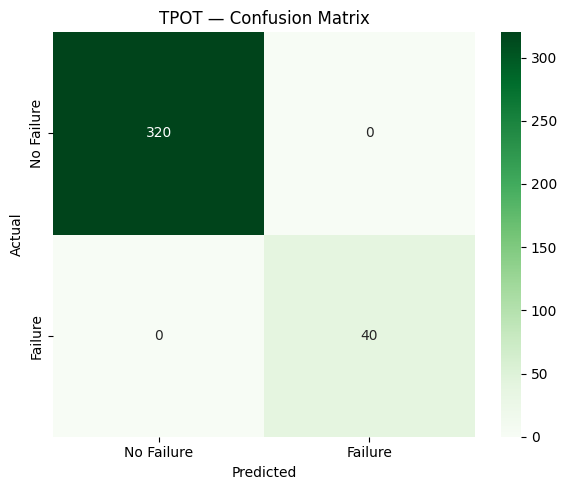

In [28]:
# ── Cell 10 : confusion matrix plot ──────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Failure', 'Failure'],
            yticklabels=['No Failure', 'Failure'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('TPOT — Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

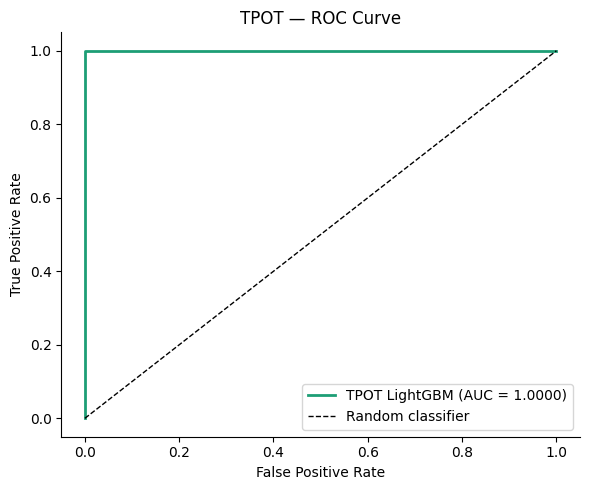

In [29]:
# ── Cell 11 : ROC curve ───────────────────────────────────────────
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='#1D9E75', lw=2,
        label=f'TPOT LightGBM (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('TPOT — ROC Curve')
ax.legend(loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
 
# First, let's see what steps are actually in the pipeline
print("Pipeline steps:")
for name, step in tpot.fitted_pipeline_.steps:
    print(f"{name}: {type(step).__name__}")
 
# Find the classifier step (the last step is usually the classifier)
classifier_name = tpot.fitted_pipeline_.steps[-1][0]
classifier = tpot.fitted_pipeline_.steps[-1][1]
 
print(f"\nClassifier found: {classifier_name}")
print(f"Classifier type: {type(classifier).__name__}")
 
# Check if the classifier has feature_importances_ attribute
if hasattr(classifier, 'feature_importances_'):
    feature_names = X_train.columns.tolist()
 
    importance_df = pd.DataFrame({
        'feature': feature_names[:len(classifier.feature_importances_)],
        'importance': classifier.feature_importances_
    }).sort_values('importance', ascending=True)
 
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(importance_df['feature'], importance_df['importance'],
            color='#1D9E75')
    ax.set_title(f'TPOT — Feature Importance ({type(classifier).__name__})')
    ax.set_xlabel('Importance')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f"{type(classifier).__name__} does not have feature_importances_ attribute")
    print("Cannot plot feature importance for this classifier type")
 
    # For GaussianNB, we can show feature means by class instead
    if type(classifier).__name__ == 'GaussianNB':
        print("\nGaussianNB Feature Analysis:")
        print("Feature means for each class:")
        feature_names = X_train.columns.tolist()
        for i, class_name in enumerate(['Normal (0)', 'Failure (1)']):
            print(f"\n{class_name}:")
            for j, feature in enumerate(feature_names):
                print(f"  {feature}: {classifier.theta_[i][j]:.4f}")

Pipeline steps:
gaussiannb: GaussianNB

Classifier found: gaussiannb
Classifier type: GaussianNB
GaussianNB does not have feature_importances_ attribute
Cannot plot feature importance for this classifier type

GaussianNB Feature Analysis:
Feature means for each class:

Normal (0):
  vibration: 0.7993
  acoustic: 0.6008
  temperature: 64.9363
  current: 11.9984
  IMF_1: 0.1600
  IMF_2: -0.0019
  IMF_3: 0.0014

Failure (1):
  vibration: 1.1984
  acoustic: 0.8965
  temperature: 77.2355
  current: 15.0114
  IMF_1: 0.2366
  IMF_2: -0.0002
  IMF_3: -0.0010


In [32]:
# ── Cell 13 : save model ──────────────────────────────────────────
import joblib

joblib.dump(tpot.fitted_pipeline_, 'tpot_best_model.pkl')
print("Model saved as tpot_best_model.pkl")

# to reload later:
# model = joblib.load('tpot_best_model.pkl')
# y_pred = model.predict(X_test)

Model saved as tpot_best_model.pkl


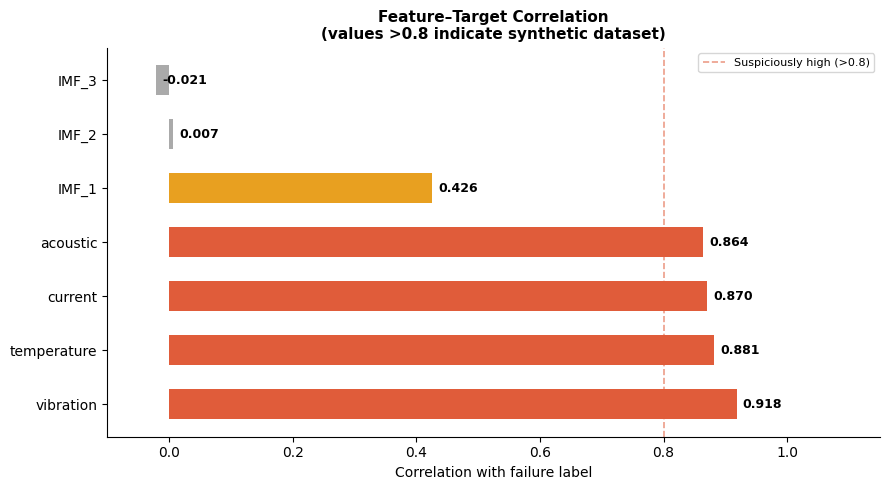

/Users/abhaysinghrana/Desktop/internship project/feature_correlation.png

In [33]:
import matplotlib.pyplot as plt

corr_data = {
    'vibration': 0.918,
    'temperature': 0.881,
    'current': 0.870,
    'acoustic': 0.864,
    'IMF_1': 0.426,
    'IMF_2': 0.007,
    'IMF_3': -0.021
}

features = list(corr_data.keys())
values   = list(corr_data.values())
colors   = ['#E05C3A' if v > 0.8 else '#E8A020' if v > 0.3 else '#AAAAAA'
            for v in values]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(features, values, color=colors, height=0.55)

# value labels
for bar, val in zip(bars, values):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

ax.axvline(x=0.8, color='#E05C3A', linestyle='--', lw=1.2, alpha=0.6,
           label='Suspiciously high (>0.8)')
ax.set_xlabel('Correlation with failure label', fontsize=10)
ax.set_title('Feature–Target Correlation\n(values >0.8 indicate synthetic dataset)',
             fontsize=11, fontweight='bold')
ax.set_xlim(-0.1, 1.15)
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

from IPython.display import FileLink, display
display(FileLink('feature_correlation.png'))

In [81]:
# ── Cell 14 : export CSV for AutoWEKA ────────────────────────────
# your teammate needs this same data for AutoWEKA
export_df = X_train.copy()
export_df['target'] = y_train.values

export_df.to_csv('train_for_autoweka.csv', index=False)

test_df = X_test.copy()
test_df['target'] = y_test.values
test_df.to_csv('test_for_autoweka.csv', index=False)

print("Exported: train_for_autoweka.csv")
print("Exported: test_for_autoweka.csv")

Exported: train_for_autoweka.csv
Exported: test_for_autoweka.csv


In [34]:
# ── Cell 15 : download everything ────────────────────────────────
from IPython.display import FileLink, display
import os

files = [
    'confusion_matrix.png',
    'roc_curve.png',
    'feature_importance.png',
    'tpot_best_model.pkl',
    'train_for_autoweka.csv',
    'test_for_autoweka.csv'
]

print("=== Download your files ===")
for f in files:
    if os.path.exists(f):
        display(FileLink(f))
        print(f"✓ {f}")
    else:
        print(f"✗ {f} not found")

=== Download your files ===


/Users/abhaysinghrana/Desktop/internship project/confusion_matrix.png

✓ confusion_matrix.png


/Users/abhaysinghrana/Desktop/internship project/roc_curve.png

✓ roc_curve.png
✗ feature_importance.png not found


/Users/abhaysinghrana/Desktop/internship project/tpot_best_model.pkl

✓ tpot_best_model.pkl
✗ train_for_autoweka.csv not found
✗ test_for_autoweka.csv not found
